# <font color='A05252'> **Examen 4**
## <font color='A05252'> **Arantza Gomez Haro Gamboa**

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation,LGBMRegressor
import lightgbm as lgb
import shap
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

## <font color='A05252'> **Datos**

In [3]:
df = pd.read_csv('hr_role.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df)

target = 'Attrition'
y = df[target]
X = df.copy()
X = X.drop(target, axis = 1)

## <font color='A05252'> **PCA**

In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pipeline.fit(X)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA())])

In [5]:
objeto_pca = pipeline.named_steps['pca']
X_pca = pipeline.transform(X)
x_components = pd.DataFrame(X_pca,index=X.index, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
x_components.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC44,PC45,PC46,PC47,PC48,PC49,PC50,PC51,PC52,PC53
0,-0.030304,-2.330446,-1.161395,3.217517,-0.113925,0.253495,-1.040500,0.309246,-0.448044,2.111620,...,0.014891,1.531962e-15,2.086084e-15,6.192959e-17,4.532546e-16,-5.432506e-16,-1.944498e-32,-6.963223e-16,-4.254345e-16,-6.085001e-16
1,0.049651,1.543678,-0.213908,-1.662470,0.719564,-2.208041,1.095471,-1.080794,2.427347,1.248215,...,-0.102855,-2.571133e-16,1.024939e-15,-1.555732e-15,-1.219919e-16,4.310296e-16,6.783304e-32,2.361651e-15,-5.550595e-16,3.965348e-16
2,-2.921983,0.996320,-0.206778,1.584724,-0.095803,0.098296,-2.782596,0.838934,0.416457,-0.642975,...,-0.099216,1.573595e-15,-6.270238e-16,2.007075e-16,7.308103e-16,4.004389e-16,1.136990e-32,-5.100518e-17,-9.236764e-17,-6.085001e-16
3,-1.187400,1.054261,-0.692836,2.306721,-0.228501,-2.392424,1.058589,-0.071526,-1.843889,1.818120,...,0.045951,-7.856287e-16,-4.327348e-16,-8.574739e-16,-1.139222e-15,-3.212060e-16,4.526627e-32,1.302079e-15,-4.254345e-16,2.796783e-16
4,-2.122667,1.196360,0.532758,-1.288092,-0.694017,1.685820,-0.501539,0.272690,-0.631277,-1.714992,...,0.148985,-4.236468e-16,-8.901959e-16,-4.177530e-16,-4.828144e-16,-7.902157e-16,1.852923e-32,3.018256e-17,2.498522e-16,5.075571e-16


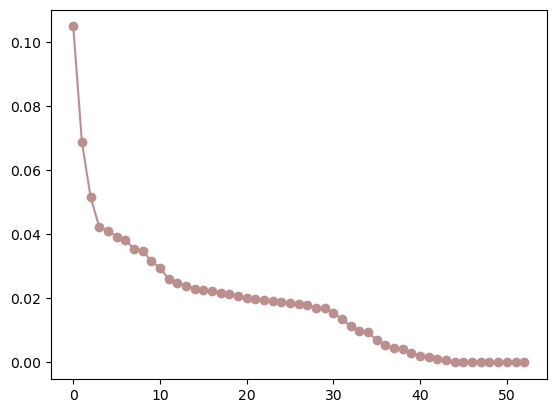

In [6]:
plt.plot(objeto_pca.explained_variance_ratio_, marker='o', color = 'rosybrown')

In [7]:
tabla = pd.DataFrame({
    'Componente 1': objeto_pca.explained_variance_ratio_[0],
    'Componente 2': objeto_pca.explained_variance_ratio_[1],
    'Componente 3': objeto_pca.explained_variance_ratio_[2],
    'Componente 4': objeto_pca.explained_variance_ratio_[3],
    'Componente 5': objeto_pca.explained_variance_ratio_[4],
    'Componente 6': objeto_pca.explained_variance_ratio_[5],
    'Componente 7': objeto_pca.explained_variance_ratio_[6],
    'Componente 8': objeto_pca.explained_variance_ratio_[7],
    'Componente 9': objeto_pca.explained_variance_ratio_[8],
    'Componente 10': objeto_pca.explained_variance_ratio_[9]
}, index = ['Varianza explicada'])
tabla

,Componente 1,Componente 2,Componente 3,Componente 4,Componente 5,Componente 6,Componente 7,Componente 8,Componente 9,Componente 10
Varianza explicada,0.104945,0.068745,0.051695,0.042252,0.041221,0.039242,0.03835,0.035444,0.034967,0.031601


#### <font color='rosybrown'> *Análisis:*

- Con los resultados anteriores se puede ver claramente cuanto explican los primeros 10 componentes de la varianza total. Dicho esto, el primer componente tiene una varianza explicada de un poco más del 10%, el segundo componente de casi 7%, y el tercer componente de aproximadamente 5%. Desde el componente 4 hasta el componente 10, cada componente explica entre el 3% y 4%. En total, las primeras 10 componentes explican el 50% de la varianza total. 
- Por otro lado, en la gráfica se puede ver como va disminuyendo el porcentaje de varianza explicada por componente. De hecho, después del componente 30, se ve como la varianza explicada ya es muy baja.

## <font color='A05252'> **Modelo KMeans**

### <font color='rosybrown'> Gráfica del codo

c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'Loss Function')

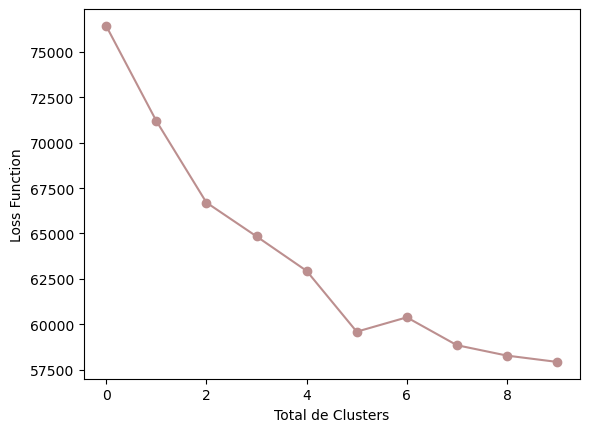

In [8]:
inertias = []

K_range = range(1, 11)
for i in K_range:
    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=i, random_state = 42))
    ])
    pipeline.fit(df)
    inertias.append(pipeline.named_steps['kmeans'].inertia_)

plt.plot(inertias, marker = "o", c = "rosybrown")
plt.xlabel("Total de Clusters")
plt.ylabel("Loss Function")

#### <font color='rosybrown'> *Análisis:*

- Con el método del codo, podemos ver que el "codo" se encuentra en 4. Esto significa que 4 es el número óptimo de clusters para cuando se aplique el modelo KMeans. A partir de este número, la disminución en la inercia es menos pronunciada, indicándonos que un aumento en la cantidad de clusters en realidad no mejoraría de manera importante el modelo. 

### <font color='rosybrown'> KMeans

In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=4))
])

pipeline.fit(df)

c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()), ('kmeans', KMeans(n_clusters=4))])

In [10]:
df['cluster'] = pipeline.predict(df)
df.groupby('cluster').mean()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,MonthlyIncome,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
cluster,,,,,,,,,,,,,,,,,,,,,
0,35.150376,0.220551,800.052632,9.388471,2.912281,2.679198,65.192982,2.696742,2.035088,5911.969925,...,0.000000,0.000000,0.786967,0.20802,0.195489,0.453634,0.350877,1.0,0.709273,0.290727
1,34.371345,0.169591,793.979532,8.850877,2.909357,2.704678,66.353801,2.786550,1.236842,3366.397661,...,0.000000,0.850877,0.000000,0.00000,0.222222,0.435673,0.342105,1.0,0.678363,0.321637
2,35.681542,0.156187,807.178499,9.430020,2.835700,2.784990,66.208925,2.713996,1.734280,4877.971602,...,0.000000,0.000000,0.000000,0.00000,0.237323,0.446247,0.316430,1.0,0.754564,0.245436
3,46.216102,0.059322,809.122881,8.860169,3.080508,2.686441,65.737288,2.737288,4.000000,15441.885593,...,0.338983,0.004237,0.050847,0.00000,0.237288,0.521186,0.241525,1.0,0.707627,0.292373


#### <font color='rosybrown'> *Análisis:*

- Como se puede ver en el dataframe anterior, se sacó el promedio de cada variable por cada cluster para poder realizar un análisis más profundo. 

    - **Cluster 0:** En el cluster 0 hay una edad promedio de 35. El attrition se encuentra en un 22%, siendo este el más alto Este cluster tiene un ingreso mensual promedio de $5,911 y un nivel de trabajo de 2, lo cual no es lo más bajo. Además, en el cluster 0 domina el trabajo de sales executive con un casi 79%.
    - **Cluster 1:** En este cluster, la edad promedio es de aproximadamente 34 años, siendo esta la más joven. Cuentan con un attrition de casi 17%. Su ingreso mensual promedio es de $3,366 y tienen un nivel de trabajo de 1.2, en ambos casos es el más bajo. El tipo de trabajo que domina en este cluster es research scientist con 85%. 
    - **Cluster 2:** En el cluster 2 la edad promedio es de casi 36 años. Tienen un attrition del 15%. El ingreso mensual promedio es de $4,877 y el nivel de trabajo es de 1.7. Este cluster se podría considerar promedio, dado que no es ni lo más alto ni lo más bajo en ninguno de los aspectos analizados.
    - **Cluster 3:** Este último cluster tiene una edad promedio de 46 años, la cual es la más alta. Tienen un attrition de 5.9%, siendo este el más bajo de los clusters. El ingreso mensual promedio es de $15,441 y el nivel de trabajo es de 4 siendo ambos los más altos de los clusters. El tipo de trabajo que domina es research director con casi 34%.
- Se puede concluir que el cluster 0 tiene un riesgo alto de rotación, esto puede ser ya que son los más jovenes y los que tienen un nivel de trabajo más bajo. Además, cuentan con los ingresos mensuales más bajos. Por otro lado, el cluster 3 tiene muy poca rotación ya que son los de mayor edad y con niveles de trabajo y sueldos más altos. 

## <font color='A05252'> **LightGBM con Variables**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = LGBMClassifier(
    n_estimators=100_000,
    num_leaves=10,
    learning_rate=0.1,
    max_depth=6,
    lambda_l2=0.1,
    subsample=0.8,
    feature_fraction=0.8,
    verbosity=-1
)

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
          eval_metric='auc',
          callbacks=[early_stopping(40),
                     log_evaluation(100)])

predicciones_lgbm = model.predict_proba(X_test)[:,1]
auc_lgbm = roc_auc_score(y_test, predicciones_lgbm)
auc_lgbm

Training until validation scores don't improve for 40 rounds
[100]	training's auc: 0.997795	training's binary_logloss: 0.117939	valid_1's auc: 0.785923	valid_1's binary_logloss: 0.322622
Early stopping, best iteration is:
[77]	training's auc: 0.992755	training's binary_logloss: 0.147445	valid_1's auc: 0.78009	valid_1's binary_logloss: 0.322332


0.7800904977375566

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

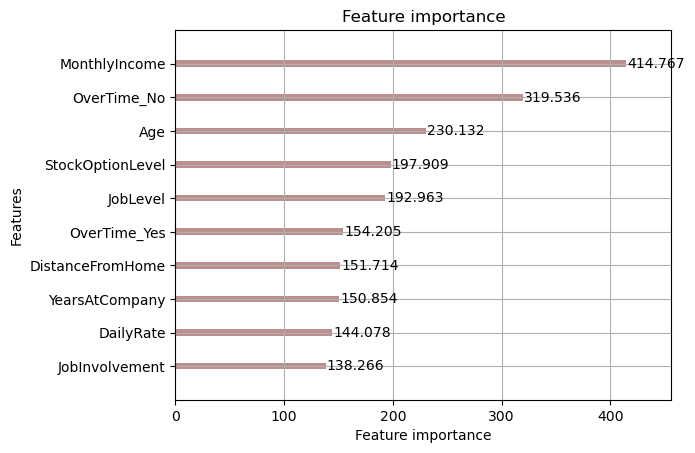

In [13]:
lgb.plot_importance(model, max_num_features = 10, importance_type='gain', color = 'rosybrown')

#### <font color='rosybrown'> *Análisis:*

- El modelo LightGBM utilizando todas las variables obtuvo un valor de AUC de 0.78, el cual es bastante bueno ya que indica una buena capacidad de distinguir entre clases. Al realizar el feature importance, se puede ver que las variables más importantes son las siguientes:
    - Monthly Income
    - Overtime No
    - Age
- Estas variables son las que más ayudan a reducir el error del model, ya que son las variables que ayudan a hacer splits para mejorar la clasificación de las variables.

### <font color='rosybrown'> Shap Values

In [14]:
X_shap = X_test.sample(290, random_state=42)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

c:\Users\arant\anaconda3\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


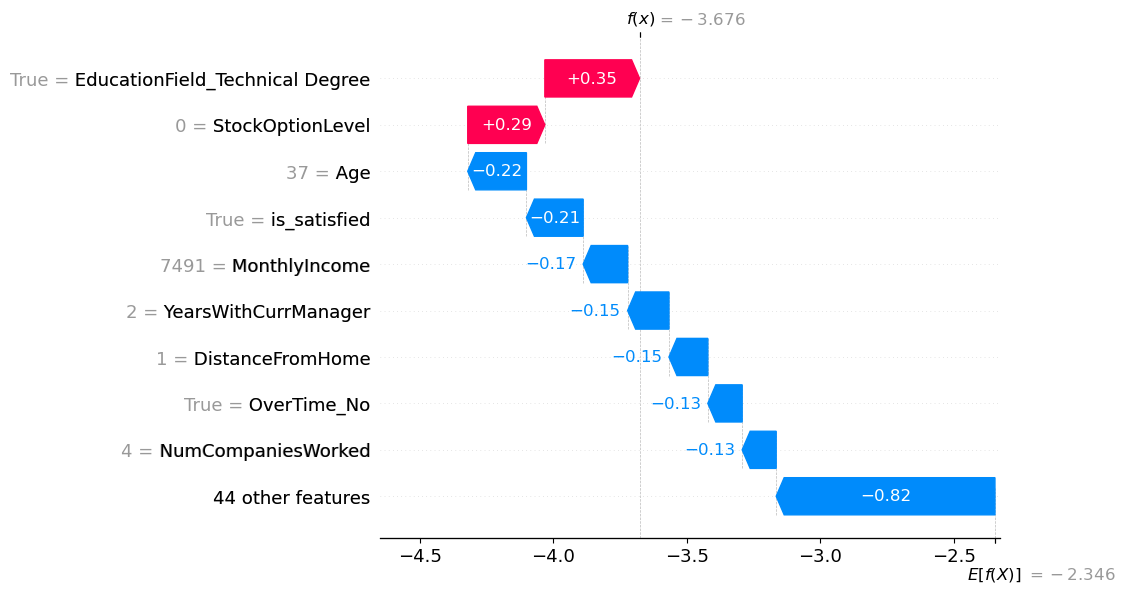

In [15]:
shap.initjs()

shap.plots.waterfall(shap.Explanation(
    values = shap_values[0],
    base_values = explainer.expected_value,
    data = X_shap.iloc[0],
    feature_names = X_shap.keys()
))

#### <font color='rosybrown'> *Análisis:*

- Con lal gráfica anterior, se puede ver que la persona que se esta analizando específicamente sigue en la empresa, esto es debido a que fue clasificado con un 0. Las variables nos indican que esta persona tiene buena experiencia y educación, ya que a trabajado en otras 4 empresas, tiene buen nivel de educación y lleva 2 años con su manager actual, razones por las cuales sigue en la empresa. Además, sus ingresos mensuales son de $7,491, los cuales son muy decentes, y tiene una edad de 37 años, lo cual no es de los más jovenes. 

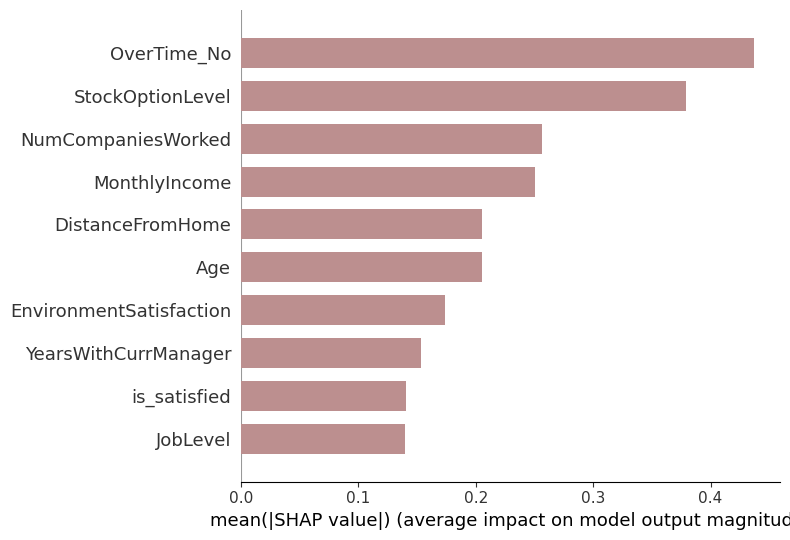

In [16]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display = 10, color = "rosybrown")

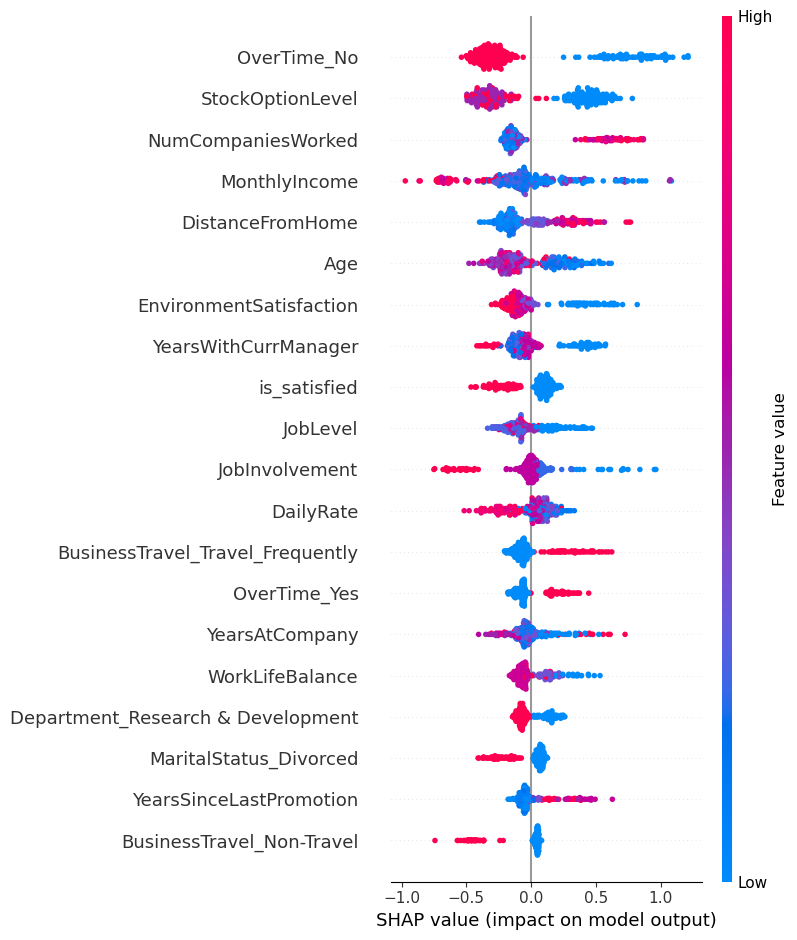

In [17]:
shap.summary_plot(shap_values, X_shap, plot_type="dot")

#### <font color='rosybrown'> *Análisis:*

- La primera gráfica nos indica el impacto promedio que tienen las variables al momento de clasificar. Las variables que más impactan en promedio nuestro target de attrition son las siguientes:
    - OverTime No
    - Stock Option Level
    - Number of Companies Worked
    - Monthly Income
- Es decir, es importante ver si es que una persona trabaja horas extras o no, cual es su nivel de opciones, la cantidad de empresas en las que a trabajado y su ingreso mensual. Todo esto permite el modelo clasificar mejor si una persona se va o se queda en la empresa. Además, es importante mencionar que algunas de estas variables (OverTime No y Monthly Income) ya han aparecido múltiples veces en nuestro análisis general, resaltando su importancia en la capacidad de predicción del modelo.

- Por otro lado, todo esto también se puede apreciar en la segunda gráfica, donde se puede ver más específicamente el impacto de las variables en el modelo. Por ejemplo, se puede ver que el no hacer horas extras disminuye la probabilidad de rotación, mientras que el haber trabajado en múltiples compañías incrementa la robabilidad de esto. Por otro lado, personas con más stock options tienden a quedarse en la empresa, al igual que personas de mayor edad.

## <font color='A05252'> **LightGBM con los componentes principales**

In [18]:
x_train_c = x_components.loc[X_train.index]
x_test_c = x_components.loc[X_test.index]

In [19]:
model_c = LGBMClassifier(
    n_estimators=100_000,
    num_leaves=6,
    learning_rate=0.1,
    max_depth=5,
    lambda_l2=0.1,
    subsample=0.8,
    feature_fraction=0.8,
    verbosity=-1
)

model_c.fit(x_train_c, y_train, eval_set=[(x_train_c, y_train), (x_test_c, y_test)],
          eval_metric='auc',
          callbacks=[early_stopping(40),
                     log_evaluation(100)])

predicciones_lgbm_c = model_c.predict_proba(x_test_c)[:,1]
auc_lgbm_c = roc_auc_score(y_test, predicciones_lgbm_c)
auc_lgbm_c

Training until validation scores don't improve for 40 rounds
[100]	training's auc: 0.997439	training's binary_logloss: 0.139845	valid_1's auc: 0.765108	valid_1's binary_logloss: 0.33065
Early stopping, best iteration is:
[69]	training's auc: 0.989599	training's binary_logloss: 0.180534	valid_1's auc: 0.77275	valid_1's binary_logloss: 0.32299


0.7727501256913022

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

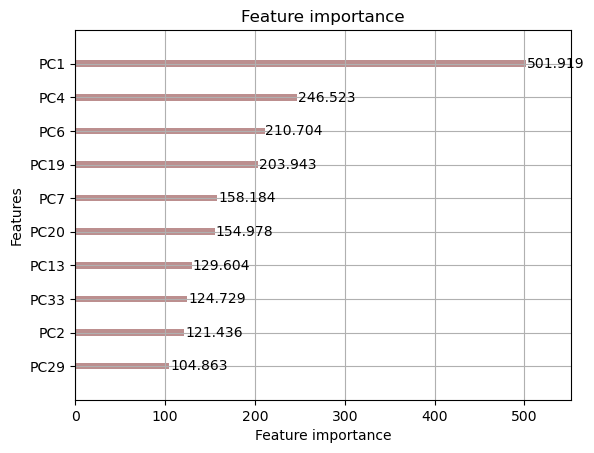

In [20]:
lgb.plot_importance(model_c, max_num_features = 10, importance_type='gain', color = 'rosybrown')

#### <font color='rosybrown'> *Análisis:*

- Con el modelo anterior, el cual utilizó todas las variables, se puede ver que se obtuvo un AUC de 0.77, indicando una buena capacidad de clasificación. También, podemos ver claramente que el componente más importante en este modelo es el 1, superando por mucho a las demás, seguido por el 4, 6 y 19. Cabe mencionar que estas componentes son esenciales para poder reducir la cantidad de información que utiliza el modelo, y así solamente mantener la información realmente importante y significativa. 

## <font color='A05252'> **LightGBM con componentes más importantes**

In [25]:
x_train_n = x_train_c[['PC1', 'PC4', 'PC6', 'PC19']]
x_test_n = x_test_c[['PC1', 'PC4', 'PC6', 'PC19']]

In [28]:
model_n = LGBMClassifier(
    n_estimators=100_000,
    num_leaves=6,
    learning_rate=0.1,
    max_depth=5,
    lambda_l2=0.1,
    subsample=0.8,
    feature_fraction=0.8,
    verbosity=-1
)

model_n.fit(x_train_n, y_train, eval_set=[(x_train_n, y_train), (x_test_n, y_test)],
          eval_metric='auc',
          callbacks=[early_stopping(40),
                     log_evaluation(100)])

predicciones_lgbm_n = model_n.predict_proba(x_test_n)[:,1]
auc_lgbm_n = roc_auc_score(y_test, predicciones_lgbm_n)
auc_lgbm_n

Training until validation scores don't improve for 40 rounds
Early stopping, best iteration is:
[10]	training's auc: 0.810733	training's binary_logloss: 0.37655	valid_1's auc: 0.665611	valid_1's binary_logloss: 0.379087


0.6656108597285066

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

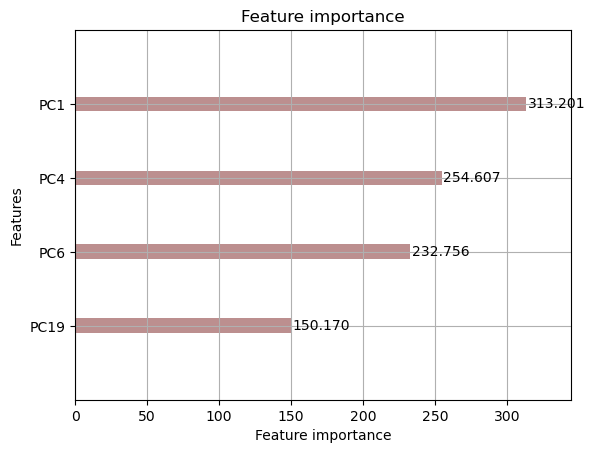

In [30]:
lgb.plot_importance(model_n, max_num_features = 10, importance_type='gain', color = 'rosybrown')

#### <font color='rosybrown'> *Análisis:*

- Con el modelo anterior, el cual utilizó solamente los componentes más importantes (PC 1, PC 4, PC 6 Y PC 19), se puede ver que se obtuvo un AUC de 0.66, indicando una capacidad media de clasificación. También, podemos ver claramente que el componente más importante en este modelo es el 1, al igual que en el modelo anterior, seguido por el 4, 6 y 19. Como ya se mencionó, estas componentes son esenciales para poder reducir la cantidad de información que utiliza el modelo, y así solamente mantener la información realmente importante y significativa. Dicho esto, el modelo aún cuenta con una precisión media solamente utilizando 4 componentes, lo cual demuestra buena área de mejora.

## <font color='A05252'> **Histogramas**

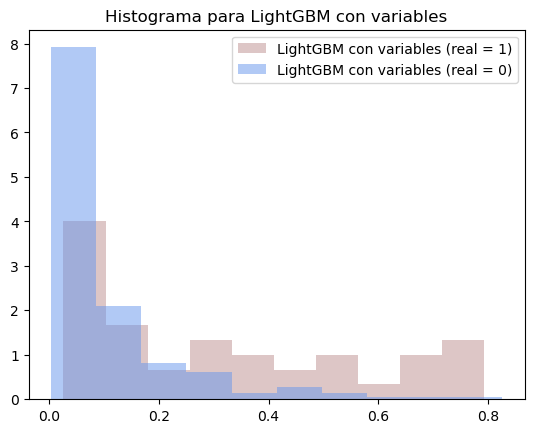

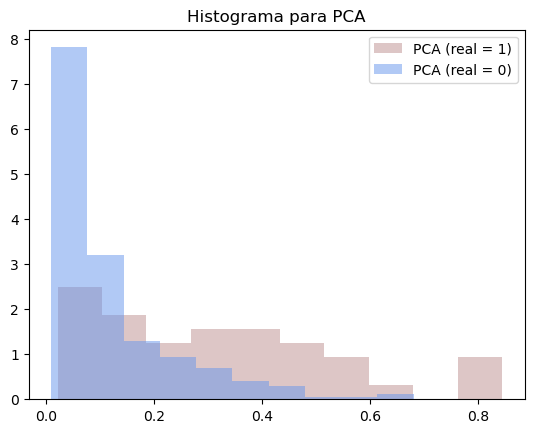

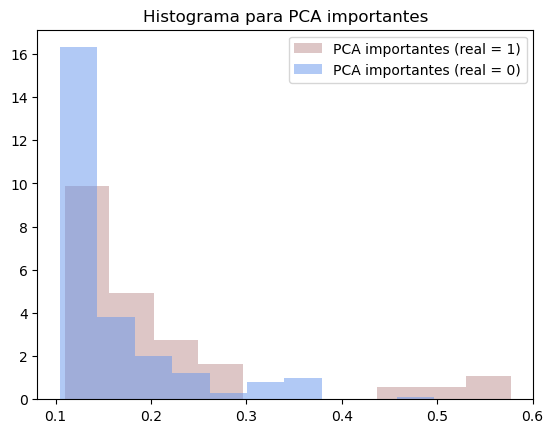

In [33]:
histogramas = pd.DataFrame({
    'real': y_test,
    'LightGBM con variables': predicciones_lgbm,
    'PCA': predicciones_lgbm_c,
    'PCA importantes': predicciones_lgbm_n
})

real1 = histogramas[histogramas['real'] == 1]
real0 = histogramas[histogramas['real'] == 0]

modelos = ['LightGBM con variables', 'PCA','PCA importantes']

for modelo in modelos:
    plt.hist(real1[modelo], density=True, alpha=0.5, bins=10, color='rosybrown', label=f'{modelo} (real = 1)')
    plt.hist(real0[modelo], density=True, alpha=0.5, bins=10, color='cornflowerblue', label=f'{modelo} (real = 0)')
    plt.title(f'Histograma para {modelo}')
    plt.legend()
    plt.show()

## <font color='A05252'> **Curva ROC**

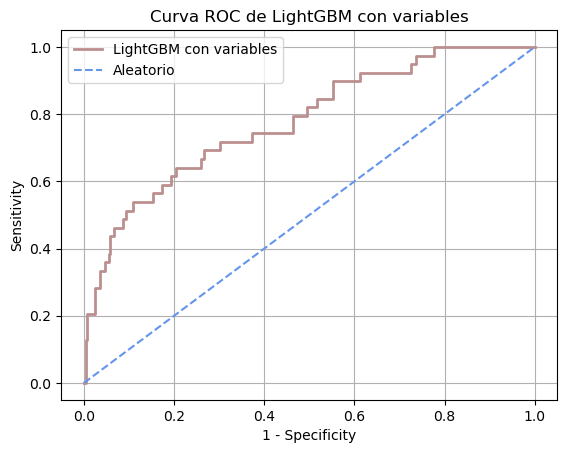

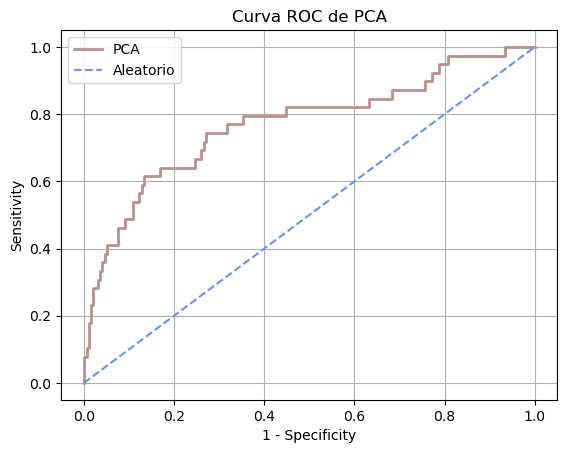

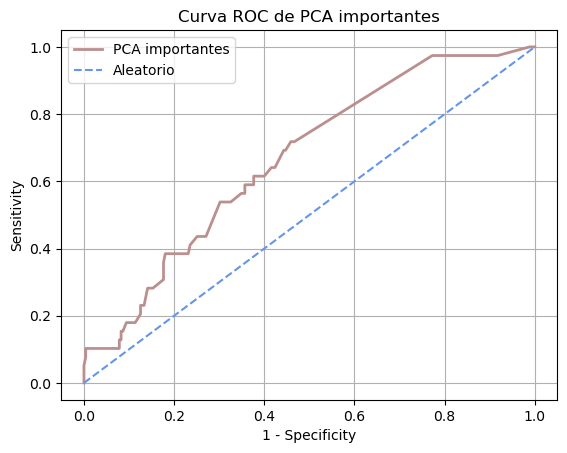

In [34]:
resultados = [predicciones_lgbm, predicciones_lgbm_c, predicciones_lgbm_n]

for i, modelo in enumerate(modelos):
    predicciones = resultados[i]
    fpr, tpr, _ = roc_curve(y_true=y_test, y_score=predicciones) 
    plt.plot(fpr, tpr, label=f'{modelo}', color='rosybrown', lw=2)
    plt.plot([0, 1], [0, 1], color='cornflowerblue', linestyle='--', lw=1.5, label='Aleatorio')
    plt.title(f'Curva ROC de {modelo}')
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.legend()
    plt.grid(True)
    plt.show()

## <font color='A05252'> **AUC**

In [35]:
tabla = pd.DataFrame({
    'LightGBM con variables': auc_lgbm,
    'PCA': auc_lgbm_c,
    'PCA importantes': auc_lgbm_n
}, index=['AUC'])
tabla

,LightGBM con variables,PCA,PCA importantes
AUC,0.78009,0.77275,0.665611


#### <font color='rosybrown'> *Análisis:*

- Tras realizar ambos modelos, se puede ver que el modelo con mayor AUC fue el lightGBM con todas las variables, con un AUC de 0.78. Es decir, las variables cuentan con información fundamental para la capacidad predictiva del modelo. Esta pequeña diferencia en la precisión del modelo, a comparación del modelo donde se utilizaron todas las componentes, se debe a la cantidad de componentes que se utilizaron. Al usar todas las componentes, el modelo no es óptimo, ya que utiliza información que puede ser insignificante para la predicción. Dicho esto, el peor modelo fue el que solamente utilizó 4 componentes, esto demuestra que con menos información se obtuvo un resultado decente y que puede mejorar agregando algunas componentes más, sin necesidad de utilizar todas.
- Por otro lado, las gráficas de las curvas ROC y los histogramas también demuestran esta pueña mejora en la precisión del modelo. También, demuestran como el último modelo tiene una menor precisión con los demás. 

# <font color='A05252'> **Diabetes**

In [36]:
df = pd.read_csv('diabetes.csv')
df['smoking_history'] = df['smoking_history'].map({'No Info': 0, 'never': 0, 'former': 1, 'current': 1, 'not current': 1, 'ever':1})
df = pd.get_dummies(df, columns = ['gender'])

target = 'diabetes'
y = df[target]
X = df.copy()
X = X.drop(target, axis = 1)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## <font color='A05252'> **S Learner**

In [38]:
model_t0 = LGBMClassifier(
    n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    eval_metric='auc',
    verbosity=-1  
)

# Entrenar
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), ([X_test, y_test])],
    callbacks=[
        early_stopping(20),
        log_evaluation(100)
    ])

Training until validation scores don't improve for 20 rounds
[100]	training's binary_logloss: 0.225665	valid_1's binary_logloss: 0.228702
Early stopping, best iteration is:
[106]	training's binary_logloss: 0.225518	valid_1's binary_logloss: 0.228667


LGBMClassifier(feature_fraction=0.8, lambda_l2=0.1, max_depth=6,
               n_estimators=100000, num_leaves=10, subsample=0.8, verbosity=-1)

In [39]:
x_test_counter0 = X_test.copy()
x_test_counter0['smoking_history'] = 0

x_test_counter1 = X_test.copy()
x_test_counter1['smoking_history'] = 1

In [47]:
df_cate = pd.DataFrame({
    'treatment0': model.predict_proba(x_test_counter0)[:, 1],
    'treatment1': model.predict_proba(x_test_counter1)[:, 1]
}) 

df_cate['cate'] = df_cate['treatment1'] - df_cate['treatment0']
df_cate['bins_cate']= pd.qcut(df_cate['cate'], q=5, labels=False) + 1
df_cate.groupby('bins_cate').mean()

,treatment0,treatment1,cate
bins_cate,,,
1,0.011308,0.011977,0.000669
2,0.014821,0.020459,0.005638
3,0.041296,0.053803,0.012507
4,0.105417,0.128755,0.023338
5,0.212579,0.254566,0.041987


In [48]:
df_cate.cate.describe()


count    20000.000000
mean         0.016756
std          0.015640
min         -0.042059
25%          0.004643
50%          0.012799
75%          0.026369
max          0.231419
Name: cate, dtype: float64

#### <font color='rosybrown'> *Análisis:*

- Con el S Learner que se realizó anteriormente, podemos ver que el fumar o no tiene cierto impacto en aumentar la probabilidad de que alguien tenga diabetes. En promedio, el fumar aumenta la probabilidad de tener diabetes en un 1.67%, y aunque no es muy alto, aún existe este pequeño aumento promedio en la probabilidad de tener esta enfermedad. De hecho, el valor máximo es de 23%, lo cual si es un aumento mayor en la probabilidad. Por otro lado, con los bins y cate, podemos ver que los grupos o bins mayores resultan en un mayor cate. Es decir, el bin 5 tiene una probabilidad de 4.19% de tener diabetes. Aunque este porcentaje sigue siendo no muy alto, se puede ver como la probabilidad puede ir aumentando.

## <font color='A05252'> **T Learner**

In [49]:
X_train_smoke1 = X_train[X_train['smoking_history'] == 1]
y_train_smoke1 = y_train.loc[X_train_smoke1.index]

X_train_smoke0 = X_train[X_train['smoking_history'] == 0]
y_train_smoke0 = y_train.loc[X_train_smoke0.index]

X_test_smoke1 = X_test[X_test['smoking_history'] == 1]
y_test_smoke1 = y_test.loc[X_test_smoke1.index]

X_test_smoke0 = X_test[X_test['smoking_history'] == 0]
y_test_smoke0 = y_test.loc[X_test_smoke0.index]

y_train_smoke = X_train['smoking_history'].reset_index(drop=True)
y_test_smoke = X_test['smoking_history'].reset_index(drop=True)

In [50]:
model_t0 = LGBMClassifier(
    n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)

# Entrenar
model_t0.fit(
    X_train_smoke0, y_train_smoke0,
    eval_set=[(X_train_smoke0, y_train_smoke0), (X_test_smoke0, y_test_smoke0)],
    callbacks=[
        early_stopping(20),
        log_evaluation(100)
    ])

Training until validation scores don't improve for 20 rounds
[100]	training's rmse: 0.230718	valid_1's rmse: 0.23486
Early stopping, best iteration is:
[91]	training's rmse: 0.230855	valid_1's rmse: 0.234845


LGBMClassifier(colsample_bytree=0.8, max_depth=5, metric='rmse',
               n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
               verbosity=-1)

In [51]:
model_t1 = LGBMClassifier(
    n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)

# Entrenar
model_t1.fit(
    X_train_smoke1, y_train_smoke1,
    eval_set=[(X_train_smoke1, y_train_smoke1), (X_test_smoke1, y_test_smoke1)],
    callbacks=[
        early_stopping(20),
        log_evaluation(100)
    ])

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[62]	training's rmse: 0.307573	valid_1's rmse: 0.306103


LGBMClassifier(colsample_bytree=0.8, max_depth=5, metric='rmse',
               n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
               verbosity=-1)

In [53]:
todos = X_test.copy()
todos = todos[X_train_smoke0.keys()]

df_cate = pd.DataFrame({
    'treatment0': model_t0.predict_proba(todos)[:,1],
    'treatment1': model_t1.predict_proba(todos)[:,1]
})

df_cate['cate'] = df_cate['treatment1'] - df_cate['treatment0']
df_cate['bins_cate']= pd.qcut(df_cate['cate'], q=5, labels=False) + 1
df_cate.groupby('bins_cate').mean()

,treatment0,treatment1,cate
bins_cate,,,
1,0.087597,0.080106,-0.007491
2,0.020352,0.027168,0.006816
3,0.033572,0.045685,0.012113
4,0.076065,0.099016,0.022951
5,0.164070,0.224170,0.060100


In [54]:
df_cate.cate.describe()

count    20000.000000
mean         0.018886
std          0.028410
min         -0.403781
25%          0.005537
50%          0.012103
75%          0.027209
max          0.313564
Name: cate, dtype: float64

#### <font color='rosybrown'> *Análisis:*

- Al utilizar T Learner, se obtiene que el fumar aumenta las probabilidades de tener diabetes en un 1.88%, lo cual es cercano a lo que se obtuvo con S Learner. Por otro lado, el máximo en este caso es de 31%, un poco más elevado que el pasado. En cuestión de los bins,  el que tuvo el impacto mayor fue el bin 5. En este caso, fumar aumenta la probabilidad de tener diabetes en un 6.01%. Por otro lado, el bin 1 tiene un efecto negativo, es decir, el fumar disminuye las probabilidades de tener diabetes. Esto es un caso atípico que debe de checarse y considerar que otros factores podrían estar afectando, ya que es algo extraño que exista este efecto negativo. Esto refuerza la idea de que el fumar tiene un efecto bajo en las probabilidades de tener diabetes.

## <font color='A05252'> **X Learner**

In [55]:
D0 = y_train_smoke1 - model_t0.predict_proba(X_train_smoke1)[:,1]
D1 = model_t1.predict_proba(X_train_smoke0)[:,1]- y_train_smoke0

In [56]:
mD0 = LGBMRegressor(
     n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)
mD0.fit(X_train_smoke1, D0)

LGBMRegressor(colsample_bytree=0.8, max_depth=5, metric='rmse',
              n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
              verbosity=-1)

In [57]:
mD1 = LGBMRegressor(
     n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)
mD1.fit(X_train_smoke0, D1)

LGBMRegressor(colsample_bytree=0.8, max_depth=5, metric='rmse',
              n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
              verbosity=-1)

In [58]:
X_train_ps = X_train.drop('smoking_history', axis = 1)
X_test_ps = X_test.drop('smoking_history', axis = 1)

propensity_model = LGBMClassifier(
    n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)

propensity_model.fit(X_train_ps, y_train_smoke, eval_set=[(X_train_ps, y_train_smoke), (X_test_ps, y_test_smoke)],
                     eval_metric = 'auc',
                     callbacks = [early_stopping(20),
                                  log_evaluation(100)])

Training until validation scores don't improve for 20 rounds
[100]	training's auc: 0.691622	training's rmse: 0.431066	valid_1's auc: 0.689934	valid_1's rmse: 0.431362
Early stopping, best iteration is:
[84]	training's auc: 0.690682	training's rmse: 0.431237	valid_1's auc: 0.690063	valid_1's rmse: 0.431363


LGBMClassifier(colsample_bytree=0.8, max_depth=5, metric='rmse',
               n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
               verbosity=-1)

(array([3134.,  464.,  860., 3292., 5942., 3445., 2112.,  464.,  263.,
          24.]),
 array([0.00352424, 0.07378769, 0.14405114, 0.21431459, 0.28457804,
        0.35484149, 0.42510494, 0.49536839, 0.56563184, 0.63589529,
        0.70615874]),
 <BarContainer object of 10 artists>)

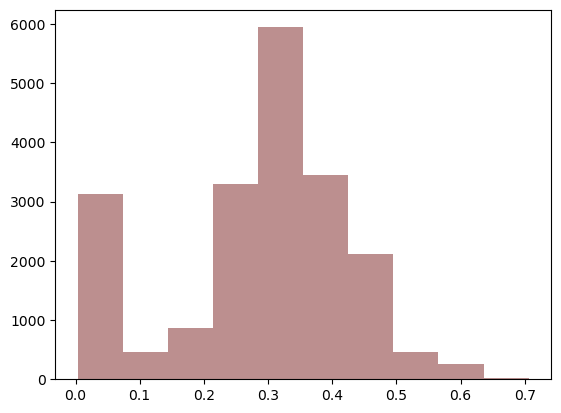

In [59]:
propensity_score = propensity_model.predict_proba(X_test_ps)[:,1]
plt.hist(propensity_score, color = "rosybrown")

In [60]:
predict_d1 = mD1.predict(X_test)
predict_d0 = mD0.predict(X_test)

In [69]:
cate = propensity_score * predict_d1 + (1-propensity_score)* predict_d0

df_cate = pd.DataFrame({
    'cate': cate
})

df_cate['bins_cate']= pd.qcut(df_cate['cate'], q=5, labels=False) + 1
df_cate.groupby('bins_cate').mean()

,cate
bins_cate,
1,-0.066642
2,-0.007805
3,0.007038
4,0.031628
5,0.127980


In [70]:
df_cate.cate.describe()

count    20000.000000
mean         0.018440
std          0.079735
min         -0.847550
25%         -0.011725
50%          0.007211
75%          0.040038
max          0.833098
Name: cate, dtype: float64

#### <font color='rosybrown'> *Análisis:*

- Por último, aplicando X Learner podemos ver que, en promedio, la probabilidad de tener diabetes por fumar aumenta en un 1.84%. Esto, al igual que en el caso anterior, es muy similar a lo que ya se ha analizado. Esto valida el efecto promedio, ya que los tres porcentajes se encuentran muy similares. El bin 5 tienen un cate mayor de 12.8%. Aunque sigue sin ser un porcentaje extremadamente alto, si aumento a comparación de los otros modelos. Además, se puede ver que aquí también hay bins (1 y 2) donde parece haber un efecto negativo, siendo casos atípicos donde podrían estar influyendo otros aspectos.

- Dicho todo lo anterior, es evidente que fumar causa un aumento en la probabilidad de tener diabetes, aunque ese aumento promedio sea poco. Que el promedio del efecto causal se encuentre entre 1.7% - 1.9% en los tres métodos refuerza esta conclusión. Tomando esto en cuenta, si existen casos donde el riesgo aumenta significativamente. 